In [15]:
def power_law_wind_speed(z:float,z_ref:float,V_ref:float,alpha:float)->float:
    """
    Returns the wind speed based on power law
    """
    if z <= 0:
        raise ValueError("Height z must be greater than zero.")

    if V_ref <= 0:
        raise ValueError("Reference wind speed V_ref must be greater than zero.")

    if z_ref <= 0:
        raise ValueError("Reference height z_ref must be greater than zero.")

    if alpha < 0:
        raise ValueError("Power-law exponent alpha cannot be negative.")
        
    Vz=V_ref*((z/z_ref)**alpha)
    return round(Vz,2)

In [16]:
power_law_wind_speed(80,10,25,0.2)

37.89

In [20]:
def power_law_wind_speed_terrain(z:float,z_ref:float,V_ref:float,terrain:str)->float:
    """
    """

    if z <= 0:
        raise ValueError("Height z must be greater than zero.")

    if V_ref <= 0:
        raise ValueError("Reference wind speed V_ref must be greater than zero.")

    if z_ref <= 0:
        raise ValueError("Reference height z_ref must be greater than zero.")

    if terrain!=("open" or "suburban" or "urban"):
        raise ValueError("Terrain should be open/suburban/urban .")
        
    alpha={"open":0.14,"suburban":0.22,"urban":0.33}
    
    Vz=V_ref*((z/z_ref)**alpha[terrain])
    return round(Vz,2)

In [21]:
power_law_wind_speed_terrain(80,10,25,'open')

33.45

In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [27]:
def power_law_wind_speed_profile(z_ref:float,V_ref:float,terrain:str):
    """
    Plots the wind speed for the given reference height(z_ref), refernce speed (V_ref) & terrain conditions
    based on power law
    """

    if V_ref <= 0:
        raise ValueError("Reference wind speed V_ref must be greater than zero.")

    if z_ref <= 0:
        raise ValueError("Reference height z_ref must be greater than zero.")

    if terrain!=("open" or "suburban" or "urban"):
        raise ValueError("Terrain should be open/suburban/urban .")
        
    alpha={"open":0.14,"suburban":0.22,"urban":0.33}

    #Heights
    z = np.linspace(1, 200, 200)
    #Calculating wind speeds    
    Vz=V_ref*((z/z_ref)**alpha[terrain])

    #Plot
    plt.figure(figsize=(6, 8))

    plt.plot(Vz, z)
    
    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Height (m)")
    plt.title("Power Law Wind Profile")
    
    plt.xlim(0, 50)
    plt.ylim(0, 200)
    
    plt.grid()
    plt.show()

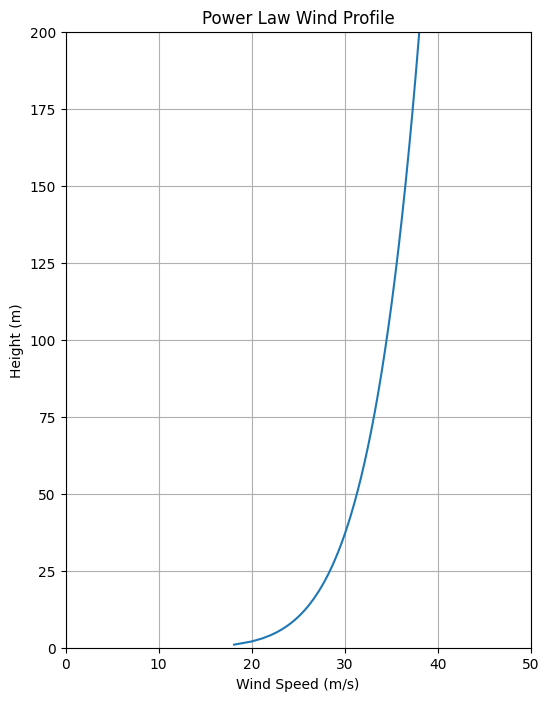

25.52974044219447


In [34]:
power_law_wind_speed_profile(10,25,'open')
print (Vz[10])

In [25]:
def power_law_profile_all_terrains(z_ref:float,V_ref:float):
    """
    """

    if V_ref <= 0:
        raise ValueError("Reference wind speed V_ref must be greater than zero.")

    if z_ref <= 0:
        raise ValueError("Reference height z_ref must be greater than zero.")
    
    z = np.linspace(1, 200, 200)    
    for terrain in ["open", "suburban", "urban"]:

        Vz = power_law_wind_speed_profile(z_ref=z_ref,V_ref=V_ref,terrain=terrain)    
        plt.plot(Vz, z, label=terrain.capitalize())


    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Height (m)")
    plt.title("Power Law Wind Profiles")
    
    plt.xlim(0, 50)
    plt.ylim(0, 200)
    
    plt.legend()
    plt.grid()
    
    plt.show()

In [16]:
def friction_velocity(z_ref:float,V_ref:float,terrain:str)->float:
    """
    """
    k=0.4
    if V_ref <= 0:
        raise ValueError("Reference wind speed V_ref must be greater than zero.")

    if z_ref <= 0:
        raise ValueError("Reference height z_ref must be greater than zero.")
    
    z0={"open":0.03,"suburban":0.3,"urban":1}
    k=0.4
    V_friction=k*V_ref/np.log(z_ref/z0[terrain])
    return round(V_friction,2)

In [17]:
friction_velocity(10,20,'suburban')

2.28

In [18]:
def logarithmic_law_wind_speed(z:float,z_ref:float,V_ref:float,terrain:str)->float:
    """
    """

    if z <= 0:
        raise ValueError("Height z must be greater than zero.")
    if terrain not in ("open", "suburban", "urban"):
        raise ValueError("Terrain should be open/suburban/urban .")
    
    z0={"open":0.03,"suburban":0.3,"urban":1}
    V_friction=friction_velocity(z_ref,V_ref,terrain)
    k=0.4
    
    Vz=(V_friction/k)*np.log(z/z0[terrain])
    return round(Vz,2)

In [19]:
logarithmic_law_wind_speed(50,10,20,"suburban")

29.16

In [22]:
def logarithmic_law_wind_speed_profile(z_ref:float,V_ref:float,terrain:str):
    """
    Plots the wind speed for the given reference height(z_ref), refernce speed (V_ref) & terrain conditions
    based on logarithmic law
    """

    if V_ref <= 0:
        raise ValueError("Reference wind speed V_ref must be greater than zero.")

    if z_ref <= 0:
        raise ValueError("Reference height z_ref must be greater than zero.")

    if terrain not in ("open", "suburban", "urban"):
        raise ValueError("Terrain should be open/suburban/urban .")
        
    z0={"open":0.03,"suburban":0.3,"urban":1}
    #Heights
    z = np.linspace(1, 200, 200)
    V_friction=friction_velocity(z_ref,V_ref,terrain)
    k=0.4
    #Calculating wind speeds 
    Vz=(V_friction/k)*np.log(z/z0[terrain])

    #Plot
    plt.figure(figsize=(6, 8))

    plt.plot(Vz, z)
    
    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Height (m)")
    plt.title("Logarithmic Law Wind Profile")
    
    plt.xlim(0, 50)
    plt.ylim(0, 200)
    
    plt.grid()
    plt.show()

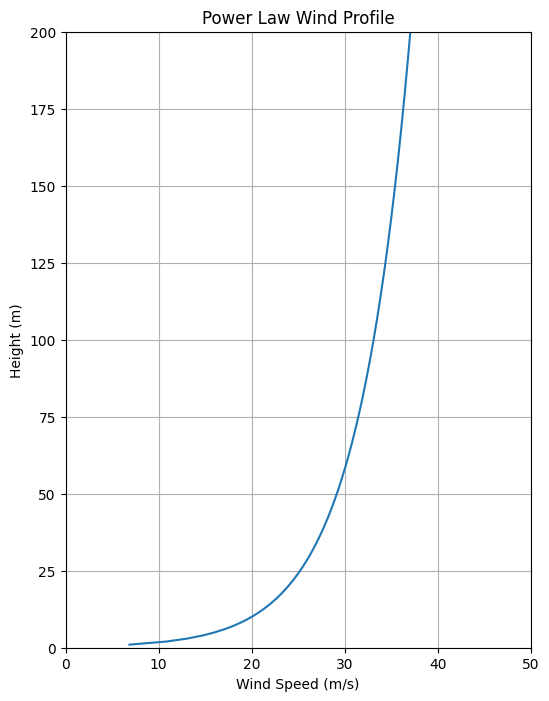

In [23]:
logarithmic_law_wind_speed_profile(10,20,'suburban')

In [15]:
def turbulence_intensity(mean_Vz:float,std_dev:float)->float:
    """
    """
    TI=std_dev/mean_Vz
    return round(TI,2)

In [26]:
turbulence_intensity(20,3)

0.15

In [28]:
def turbulence_std_dev(ti:float,mean_Vz:float)->float:
    """
    """
    std_dev=ti*mean_Vz
    return round(std_dev)

In [29]:
turbulence_std_dev(0.15,20)

3

In [1]:

import numpy as np
def wind_fluctuation(wind_speed):
    """
    Calculates mean wind speed, turbulent fluctuations and turbulent intensity
    from measured wind-speed data.
    """

    wind_speed = np.asarray(wind_speed, dtype=float)

    mean_wind_speed = np.mean(wind_speed)

    fluctuations = wind_speed - mean_wind_speed

    std_dev=np.std(fluctuations)

    TI=turbulence_intensity(mean_wind_speed,std_dev)

    return mean_wind_speed,fluctuations,round(std_dev,2),TI


In [21]:
wind_speed = [10.2, 11.1, 9.8, 10.7, 10.4]
wind_fluctuation(wind_speed)


(10.44, array([-0.24,  0.66, -0.64,  0.26, -0.04]), 0.44, 0.04)

In [9]:
def auto_correlation(fluctuations):
    """
    """
    #Correlating the fluctuations with both negative and positive shifts
    correlation=np.correlate(fluctuations,fluctuations,"full")
    #Considering only positive shifts because we're interested in how does correlation decay as we move forward in time
    correlation=correlation[correlation.size//2:]
    #Normalilizing the correlation 
    #At zero lag, the wind signal is being compared with itself without any shift, so it should represent perfect correlation.
    correlation=correlation/correlation[0]
    return np.round(correlation,2)

In [8]:
auto_correlation([1, 2, 1])

array([1.  , 0.67, 0.17])

In [23]:
def integral_time_scale(fluctuations, sampling_freq: float):
    """
    Calculate integral turbulence time scale.
    """

    if sampling_freq <= 0:
        raise ValueError("Sampling frequency must be greater than zero.")

    dt = 1 / sampling_freq

    R = auto_correlation(fluctuations)

    zero_crossing = np.where(R <= 0)[0]

    if len(zero_crossing) == 0:
        raise ValueError("Autocorrelation does not cross zero.")

    first_zero = zero_crossing[0]

    # Exact zero crossing
    if R[first_zero] == 0:

        Tu = np.trapezoid(
            R[:first_zero + 1],
            dx=dt
        )

    else:

        R1 = R[first_zero - 1]
        R2 = R[first_zero]

        t1 = (first_zero - 1) * dt
        t2 = first_zero * dt

        # Interpolated zero-crossing time
        t_zero = t1 - R1 * (t2 - t1) / (R2 - R1)

        # Area up to last positive autocorrelation value
        Tu = np.trapz(
            R[:first_zero],
            dx=dt
        )

        # Add final triangular area
        Tu += 0.5 * R1 * (t_zero - t1)

    return round(Tu,2)


In [24]:
integral_time_scale([2, 1, -1, -2, -1, 1],1)

0.74

In [25]:
def integral_length_scale(mean_wind_speed,time_scale):
    """
    """
    if mean_wind_speed <= 0:
        raise ValueError(
            "Mean wind speed must be greater than zero."
        )

    if time_scale <= 0:
        raise ValueError(
            "Time scale must be greater than zero."
        )

    L_u = mean_wind_speed * time_scale

    return L_u

In [26]:
integral_length_scale (15,0.74)

11.1